In [1]:
import os
import json
import time
import warnings

import cv2
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torchvision
import timm

from tqdm import tqdm

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)

warnings.filterwarnings("ignore")

d:\GECACS\Dissertation\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
#Results Folder
RESULTS_DIR = "Results"

os.makedirs(
    RESULTS_DIR,
    exist_ok=True
)

print("Results Folder Created")

Results Folder Created


In [3]:
#Paths
CHECKPOINT_DIR = "checkpoints"

BEST_MODEL = os.path.join(
    CHECKPOINT_DIR,
    "best.pth"
)

TRAIN_LOG = os.path.join(
    CHECKPOINT_DIR,
    "training_log.csv"
)

META_FILE = os.path.join(
    CHECKPOINT_DIR,
    "meta.json"
)

REPORT_FILE = os.path.join(
    CHECKPOINT_DIR,
    "test_report.json"
)

DATA_SPLIT = os.path.join(
    CHECKPOINT_DIR,
    "data_split.csv"
)

In [4]:
#check files
files = [

    BEST_MODEL,

    TRAIN_LOG,

    META_FILE,

    REPORT_FILE,

    DATA_SPLIT

]

for file in files:

    print(file)

    print(
        os.path.exists(file)
    )

checkpoints\best.pth
True
checkpoints\training_log.csv
True
checkpoints\meta.json
True
checkpoints\test_report.json
True
checkpoints\data_split.csv
True


In [5]:
#load training History 
history = pd.read_csv(
    TRAIN_LOG
)

history.head()

,epoch,train_loss,train_acc,val_acc,is_best,time_sec
0,1,0.134409,0.944713,0.972042,True,58578.994373
1,2,0.061131,0.977951,0.976533,True,63562.853163
2,3,0.048206,0.983093,0.985207,True,67607.351299
3,4,0.041000,0.985688,0.982697,False,72974.308449
4,5,0.034652,0.988084,0.986968,True,72693.786354


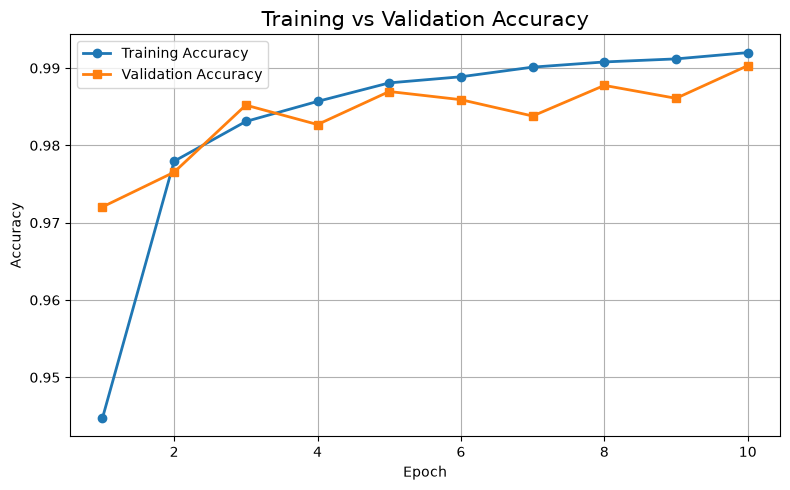

In [6]:
#Training Accuracy vs Validation Accuracy
plt.figure(figsize=(8,5))

plt.plot(
    history["epoch"],
    history["train_acc"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history["epoch"],
    history["val_acc"],
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "Training vs Validation Accuracy",
    fontsize=15
)

plt.xlabel("Epoch")

plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Training_Validation_Accuracy.png"
    ),
    dpi=300
)

plt.show()

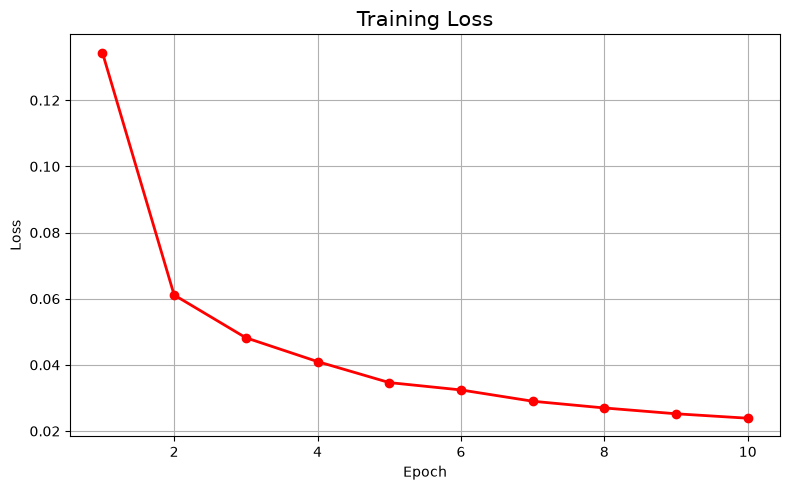

In [7]:
#Training Loss
plt.figure(figsize=(8,5))

plt.plot(
    history["epoch"],
    history["train_loss"],
    marker="o",
    linewidth=2,
    color="red"
)

plt.title(
    "Training Loss",
    fontsize=15
)

plt.xlabel("Epoch")

plt.ylabel("Loss")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Training_Loss.png"
    ),
    dpi=300
)

plt.show()

In [8]:
#Save Training History
history.to_csv(

    os.path.join(
        RESULTS_DIR,
        "Training_History.csv"
    ),

    index=False
)

print(history)

   epoch  train_loss  train_acc   val_acc  is_best      time_sec
0      1    0.134409   0.944713  0.972042     True  58578.994373
1      2    0.061131   0.977951  0.976533     True  63562.853163
2      3    0.048206   0.983093  0.985207     True  67607.351299
3      4    0.041000   0.985688  0.982697    False  72974.308449
4      5    0.034652   0.988084  0.986968     True  72693.786354
5      6    0.032427   0.988877  0.985911    False  58978.812438
6      7    0.029013   0.990122  0.983798    False  64934.460560
7      8    0.026978   0.990792  0.987760     True  60653.217496
8      9    0.025221   0.991188  0.986087    False  59433.353700
9     10    0.023879   0.991999  0.990314     True  59716.843972


In [9]:
split = pd.read_csv("checkpoints/data_split.csv")

print(split.head())

print(split.columns)

                                                path  label  split
0  D:\GECACS\Dissertation\datasets\NTHU\train\not...      0  train
1  D:\GECACS\Dissertation\datasets\NTHU\train\not...      0  train
2  D:\GECACS\Dissertation\datasets\NTHU\train\not...      0  train
3  D:\GECACS\Dissertation\datasets\MRL\data\train...      0  train
4  D:\GECACS\Dissertation\datasets\MRL\data\train...      1  train
Index(['path', 'label', 'split'], dtype='str')


In [10]:

# Load saved data split
split_df = pd.read_csv(DATA_SPLIT)

# Use only test samples
test_df = split_df[
    split_df["split"] == "test"
].reset_index(drop=True)

print("Total Test Images :", len(test_df))

test_df.head()

Total Test Images : 22713


,path,label,split
0,D:\GECACS\Dissertation\datasets\MRL\data\train...,0,test
1,D:\GECACS\Dissertation\datasets\NTHU\train\dro...,1,test
2,D:\GECACS\Dissertation\datasets\NTHU\train\not...,0,test
3,D:\GECACS\Dissertation\datasets\NTHU\train\not...,0,test
4,D:\GECACS\Dissertation\datasets\MRL\data\val\a...,0,test


In [11]:
#Dataset Class
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

IMG_SIZE = 224

transform = transforms.Compose([
    transforms.ToPILImage(),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        [0.485,0.456,0.406],
        [0.229,0.224,0.225]
    )
])


class TestDataset(Dataset):

    def __init__(self, dataframe):

        self.df = dataframe

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        img = cv2.imread(
            self.df.iloc[idx]["path"]
        )

        img = cv2.cvtColor(
            img,
            cv2.COLOR_BGR2RGB
        )

        img = transform(img)

        # Same pseudo sequence used during training
        img = torch.stack([img]*4)

        label = int(
            self.df.iloc[idx]["label"]
        )

        return img, label

In [12]:
#Test Loader
test_dataset = TestDataset(
    test_df
)

test_loader = DataLoader(
    test_dataset,
    batch_size=8,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Test batches :", len(test_loader))

Test batches : 2840


In [13]:
#Model Definition
class TemporalAttention(nn.Module):

    def __init__(self, hidden_dim):
        super().__init__()
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, hidden_dim),
            nn.Tanh(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, lstm_out):
        scores = self.attention(lstm_out)
        weights = torch.softmax(scores, dim=1)
        context = torch.sum(weights * lstm_out, dim=1)
        return context

In [14]:
#Model Definition
class CNN_LSTM_ViT(nn.Module):

    def __init__(self):
        super().__init__()

        mobilenet = torchvision.models.mobilenet_v3_large(
            weights=torchvision.models.MobileNet_V3_Large_Weights.DEFAULT
        )
        self.cnn = mobilenet.features
        self.pool = nn.AdaptiveAvgPool2d(1)
        cnn_dim = 960

        self.lstm = nn.LSTM(
            input_size=cnn_dim, hidden_size=128, num_layers=2,
            batch_first=True, bidirectional=True, dropout=0.3,
        )

        self.attention = TemporalAttention(128)

        self.vit = timm.create_model("vit_tiny_patch16_224", pretrained=True, num_classes=0)
        vit_dim = 192

        self.classifier = nn.Sequential(
            nn.Linear(256 + vit_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 64),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(64, 2),
        )

    def forward(self, x):
        B, T, C, H, W = x.shape
        cnn_input = x.view(B * T, C, H, W)
        cnn_features = self.cnn(cnn_input)
        cnn_features = self.pool(cnn_features).flatten(1)
        cnn_features = cnn_features.view(B, T, -1)

        lstm_out, _ = self.lstm(cnn_features)
        temporal_features = self.attention(lstm_out)

        last_frame = x[:, -1]
        vit_features = self.vit(last_frame)

        fusion = torch.cat([temporal_features, vit_features], dim=1)
        output = self.classifier(fusion)
        return output

In [15]:
#Load Best Model
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

model = CNN_LSTM_ViT().to(device)

checkpoint = torch.load(
    BEST_MODEL,
    map_location=device
)

# Supports both state_dict-only and checkpoint dictionary formats
if isinstance(checkpoint, dict) and "model_state" in checkpoint:
    model.load_state_dict(checkpoint["model_state"])
else:
    model.load_state_dict(checkpoint)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


In [ ]:
#Run Inference on Test Set
predictions = []
probabilities = []
targets = []

model.eval()

with torch.no_grad():

    for images, labels in tqdm(test_loader):

        images = images.to(device)

        outputs = model(images)

        probs = torch.softmax(outputs, dim=1)

        pred = probs.argmax(1)

        predictions.extend(pred.cpu().numpy())

        probabilities.extend(probs[:,1].cpu().numpy())

        targets.extend(labels.numpy())

  0%|          | 0/2840 [00:00<?, ?it/s]

In [ ]:
#Calculate Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    roc_auc_score
)

accuracy = accuracy_score(targets, predictions)

precision = precision_score(targets, predictions)

recall = recall_score(targets, predictions)

f1 = f1_score(targets, predictions)

roc_auc = roc_auc_score(targets, probabilities)

cm = confusion_matrix(targets, predictions)

TN, FP, FN, TP = cm.ravel()

specificity = TN / (TN + FP)

sensitivity = TP / (TP + FN)

metrics = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Specificity",
        "Sensitivity",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        sensitivity,
        roc_auc
    ]

})

metrics

In [ ]:
#save Metrics
metrics.to_csv(

    os.path.join(
        RESULTS_DIR,
        "evaluation_metrics.csv"
    ),

    index=False
)

print(metrics)

In [ ]:
#Classification Report
from sklearn.metrics import classification_report

report = classification_report(

    targets,

    predictions,

    digits=4,

    output_dict=True

)

report_df = pd.DataFrame(report).transpose()

report_df.to_csv(

    os.path.join(
        RESULTS_DIR,
        "classification_report.csv"
    )

)

print(report_df)

In [ ]:
#Save Predictions
pred_df = pd.DataFrame({

    "Actual":targets,

    "Predicted":predictions,

    "Probability":probabilities

})

pred_df.to_csv(

    os.path.join(
        RESULTS_DIR,
        "predictions.csv"
    ),

    index=False
)

pred_df.head()

In [ ]:
#Confusion Matrix
plt.figure(figsize=(7,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Not Drowsy","Drowsy"],
    yticklabels=["Not Drowsy","Drowsy"]
)

plt.title(
    "Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Confusion_Matrix.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
#Normalized Confusion Matrix
cm_norm = cm.astype(float) / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(7,6))

sns.heatmap(
    cm_norm,
    annot=True,
    fmt=".3f",
    cmap="Greens",
    xticklabels=["Not Drowsy","Drowsy"],
    yticklabels=["Not Drowsy","Drowsy"]
)

plt.title(
    "Normalized Confusion Matrix",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Normalized_Confusion_Matrix.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
#ROC Curve
fpr, tpr, thresholds = roc_curve(
    targets,
    probabilities
)

plt.figure(figsize=(7,6))

plt.plot(
    fpr,
    tpr,
    linewidth=3,
    label=f"AUC = {roc_auc:.4f}"
)

plt.plot(
    [0,1],
    [0,1],
    linestyle="--",
    color="red"
)

plt.title(
    "ROC Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")

plt.legend()

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "ROC_Curve.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
#Precision Recall Curve
precision_curve, recall_curve, thresholds = precision_recall_curve(
    targets,
    probabilities
)

pr_auc = auc(
    recall_curve,
    precision_curve
)

plt.figure(figsize=(7,6))

plt.plot(
    recall_curve,
    precision_curve,
    linewidth=3,
    label=f"AUC = {pr_auc:.4f}"
)

plt.title(
    "Precision Recall Curve",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Recall")
plt.ylabel("Precision")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Precision_Recall_Curve.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
#Training Accuracy vs Validation Accuracy
plt.figure(figsize=(8,5))

plt.plot(
    history["epoch"],
    history["train_acc"],
    marker="o",
    linewidth=2,
    label="Training Accuracy"
)

plt.plot(
    history["epoch"],
    history["val_acc"],
    marker="s",
    linewidth=2,
    label="Validation Accuracy"
)

plt.title(
    "Training vs Validation Accuracy",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.grid(True)

plt.legend()

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Training_Validation_Accuracy.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
#Training Loss
plt.figure(figsize=(8,5))

plt.plot(
    history["epoch"],
    history["train_loss"],
    color="red",
    marker="o",
    linewidth=2
)

plt.title(
    "Training Loss",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    os.path.join(
        RESULTS_DIR,
        "Training_Loss.png"
    ),
    dpi=300
)

plt.show()

In [ ]:
#Save Summary Metrics
summary = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score",
        "Specificity",
        "Sensitivity",
        "ROC AUC"
    ],

    "Value":[
        accuracy,
        precision,
        recall,
        f1,
        specificity,
        sensitivity,
        roc_auc
    ]

})

summary.to_csv(
    os.path.join(
        RESULTS_DIR,
        "Summary_Metrics.csv"
    ),
    index=False
)

summary

In [ ]:
#Save JSON
summary_json = {

    "Accuracy": float(accuracy),

    "Precision": float(precision),

    "Recall": float(recall),

    "F1 Score": float(f1),

    "Specificity": float(specificity),

    "Sensitivity": float(sensitivity),

    "ROC AUC": float(roc_auc)

}

with open(

    os.path.join(
        RESULTS_DIR,
        "metrics.json"
    ),

    "w"

) as f:

    json.dump(
        summary_json,
        f,
        indent=4
    )

print("JSON saved successfully.")

In [ ]:
#Save Dissertation Summary
with open(

    os.path.join(
        RESULTS_DIR,
        "Summary_Report.txt"
    ),

    "w"

) as f:

    f.write("CNN + BiLSTM + ViT Evaluation Results\n")
    f.write("="*45 + "\n\n")

    f.write(f"Accuracy    : {accuracy:.4f}\n")
    f.write(f"Precision   : {precision:.4f}\n")
    f.write(f"Recall      : {recall:.4f}\n")
    f.write(f"F1 Score    : {f1:.4f}\n")
    f.write(f"Specificity : {specificity:.4f}\n")
    f.write(f"Sensitivity : {sensitivity:.4f}\n")
    f.write(f"ROC AUC     : {roc_auc:.4f}\n")

print("Summary report saved.")